DECISION TREE

A Decision Tree learns a series of if-else questions about the data and chains them into a flowchart. It's one of the
most interpretable ML models — you can draw it on paper and explain every decision.

A Decision Tree helps us to make decisions by mapping out different choices and their possible outcomes. It’s used in machine learning for tasks like
classification and prediction.

A Decision Tree helps us make decisions by showing different options and how they are related. It has a tree-like structure that starts with one main question called the root node which represents the entire dataset. From there, the tree branches out into different possibilities based on features in the data.

Root Node: Starting point representing the whole dataset.

Branches: Lines connecting nodes showing the flow from one decision to another.

Internal Nodes: Points where decisions are made based on data features.

Leaf Nodes: End points of the tree where the final decision or prediction is made.

The fastest way to understand a tree is to train one and visualise it:

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [2]:
tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X_train, y_train)
print(f'Train accuracy: {tree.score(X_train, y_train):.2%}')
print(f'Test accuracy: {tree.score(X_test, y_test):.2%}')

Train accuracy: 95.00%
Test accuracy: 96.67%


In [3]:
print(export_text(tree, feature_names=iris.feature_names))

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- class: 1
|   |--- petal length (cm) >  4.75
|   |   |--- class: 2



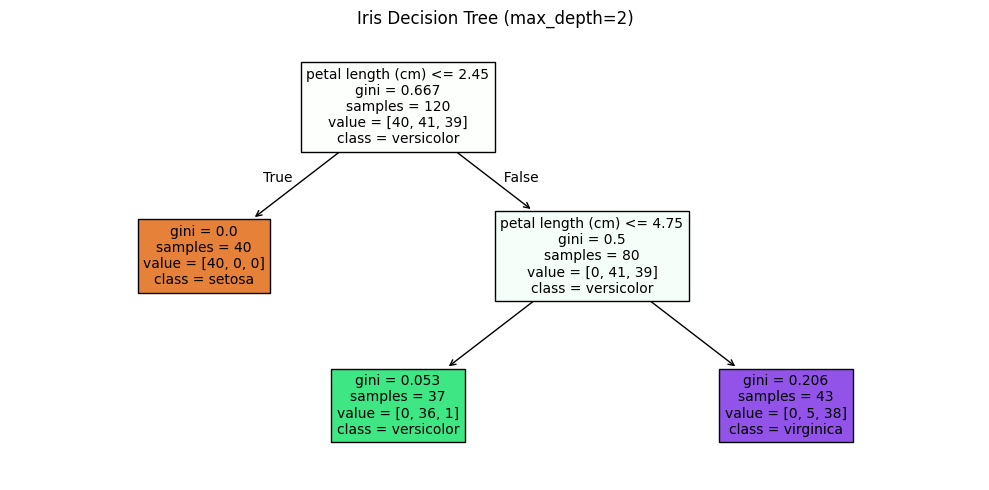

In [4]:
plt.figure(figsize=(10, 5))
plot_tree(tree, feature_names=iris.feature_names,
class_names=iris.target_names,
filled=True, rounded=False, fontsize=10)
plt.title('Iris Decision Tree (max_depth=2)'); plt.tight_layout(); plt.show()

In [5]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]
pred = tree.predict(new_flower)[0]
print(f'Predicted species: {iris.target_names[pred]}')
print(f'Probabilities : {tree.predict_proba(new_flower)[0]}')

Predicted species: setosa
Probabilities : [1. 0. 0.]


Gini impurity is a measure used in **Decision Trees** to decide how to split data. It tells how “mixed” a node is — if all data points belong to one class, Gini = 0 (pure node). If classes are mixed, Gini increases. The model chooses splits that give the **lowest Gini impurity**, meaning cleaner separation of classes.


1. Calculate Gini manually first, then let sklearn demonstrate the same logic:

In [7]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

def gini_impurity(labels):
    """Calculate Gini impurity for a list of class labels."""
    labels = np.array(labels)
    n = len(labels)
    if n == 0: return 0
    classes = np.unique(labels)
    gini = 1.0
    for c in classes:
        p = np.sum(labels == c) / n
        gini -= p ** 2
    return gini

In [8]:
print('Pure node (all same) :', gini_impurity([1,1,1,1,1]))
print('50-50 split :', gini_impurity([0,0,0,1,1,1]))
print('70-30 split :', gini_impurity([0,0,0,0,0,0,0,1,1,1]))
print('90-10 split :', gini_impurity([0]*9 + [1]))

Pure node (all same) : 0.0
50-50 split : 0.5
70-30 split : 0.42000000000000004
90-10 split : 0.17999999999999994


In [9]:
def weighted_gini(left_labels, right_labels):
    """Gini after a split — weighted by group size."""
    n_total = len(left_labels) + len(right_labels)
    w_left = len(left_labels) / n_total
    w_right = len(right_labels) / n_total
    return w_left * gini_impurity(left_labels) + w_right * gini_impurity(right_labels)

In [10]:
left_A = [0,0,0,0,1]
right_A = [0,1,1,1,1]

In [11]:
left_B = [0,0,1,1,0]
right_B = [0,1,0,1,1]

In [12]:
print(f'Weighted Gini — Glucose split: {weighted_gini(left_A, right_A):.3f}')
print(f'Weighted Gini — Age split : {weighted_gini(left_B, right_B):.3f}')
print('Tree picks the split with LOWER weighted Gini → Glucose split is better!')

Weighted Gini — Glucose split: 0.320
Weighted Gini — Age split : 0.480
Tree picks the split with LOWER weighted Gini → Glucose split is better!


In [13]:
from sklearn.datasets import make_classification
from sklearn.tree import export_text
X, y = make_classification(n_samples=200, n_features=4, random_state=42)
tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X, y)
print(export_text(tree, feature_names=['F1','F2','F3','F4']))

|--- F1 <= -0.15
|   |--- F3 <= -0.44
|   |   |--- class: 0
|   |--- F3 >  -0.44
|   |   |--- class: 0
|--- F1 >  -0.15
|   |--- F3 <= 0.63
|   |   |--- class: 1
|   |--- F3 >  0.63
|   |   |--- class: 0



**Overfitting vs Underfitting**

Overfitting happens when a model learns the training data too well, including noise and small details, so it performs very well on training data but poorly on new test data. It is like memorizing answers instead of understanding them.

Underfitting happens when a model is too simple to learn the patterns in the data, so it performs poorly on both training and test data. It fails to capture the important relationships.

In short, overfitting = too complex model, underfitting = too simple model, and the goal is to find a balance where the model generalizes well to new data.


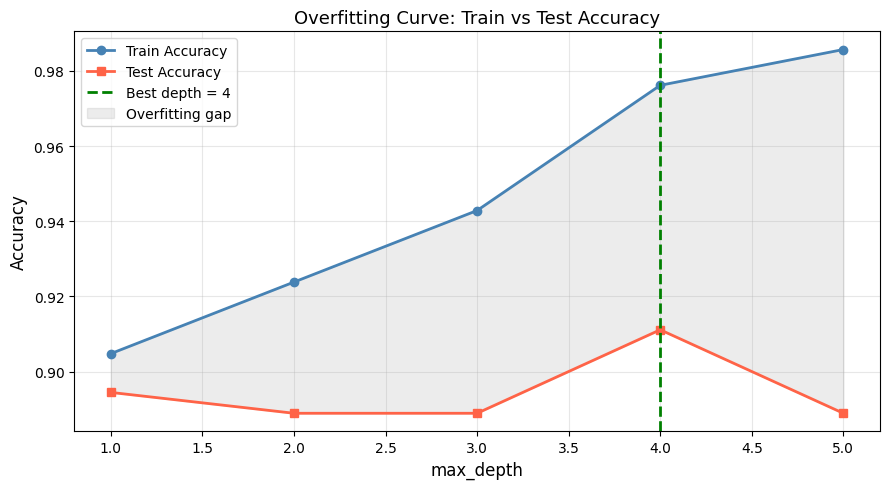

Best test accuracy 91.11% at depth=4


In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
X, y = make_classification(n_samples=600, n_features=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
depths = range(1, 6)
train_acc, test_acc = [], []
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, tree.predict(X_train)))
    test_acc.append(accuracy_score(y_test, tree.predict(X_test)))
best_depth = depths[test_acc.index(max(test_acc))]
plt.figure(figsize=(9, 5))
plt.plot(depths, train_acc, 'o-', color='steelblue', lw=2, label='Train Accuracy')
plt.plot(depths, test_acc, 's-', color='tomato', lw=2, label='Test Accuracy')
plt.axvline(x=best_depth, color='green', linestyle='--', lw=2,
            label=f'Best depth = {best_depth}')
plt.fill_between(depths,
                 train_acc, test_acc,
                 alpha=0.15, color='gray', label='Overfitting gap')
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Overfitting Curve: Train vs Test Accuracy', fontsize=13)
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


print(f'Best test accuracy {max(test_acc):.2%} at depth={best_depth}')

Other Anti-Overfitting Parameters

max_depth is not the only tool — here are the other key parameters:

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

configs = [
{'max_depth': None},
{'max_depth': 5},
{'max_depth': 5, 'min_samples_split': 10},
{'max_depth': 5, 'min_samples_leaf': 5},
{'max_depth': 5, 'max_features': 'sqrt'},
]

print(f'{'Config':45s} {'CV Score (mean±std)':20s}')
print('-' * 60)


for cfg in configs:
  tree = DecisionTreeClassifier(**cfg, random_state=42)
  scores = cross_val_score(tree, X, y, cv=7, scoring='accuracy')
  print(f'{str(cfg):45s} {scores.mean():.3f} ± {scores.std():.3f}')


Config                                        CV Score (mean±std) 
------------------------------------------------------------
{'max_depth': None}                           0.883 ± 0.039
{'max_depth': 5}                              0.887 ± 0.041
{'max_depth': 5, 'min_samples_split': 10}     0.885 ± 0.037
{'max_depth': 5, 'min_samples_leaf': 5}       0.895 ± 0.037
{'max_depth': 5, 'max_features': 'sqrt'}      0.872 ± 0.036


**Random Forest**

Random Forest is an ensemble learning algorithm that builds multiple Decision Trees and combines their outputs to get a more accurate and stable prediction. Instead of relying on one tree (which can overfit), it takes the majority vote (classification) or average (regression) from many trees.

Each tree is trained on a random sample of data and features, which makes the model less correlated and improves performance. This reduces overfitting and increases accuracy compared to a single Decision Tree.

In short, Random Forest = many decision trees + voting/averaging → better and more reliable predictions.


OOB Score, Voting, and n_estimators Sweep

Three demonstrations: OOB validation, manual voting insight, and the n_estimators trade-off:

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np, matplotlib.pyplot as plt, time

X, y = make_classification(n_samples=1000, n_features=15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
rf_oob = RandomForestClassifier(n_estimators=10, oob_score=True, random_state=42)
rf_oob.fit(X_train, y_train)
print(f'OOB Score : {rf_oob.oob_score_:.2%} ← estimated on ~37% unseen rows per tree')
print(f'Test Score : {rf_oob.score(X_test, y_test):.2%} ← actual held-out test')
print('OOB score is a free estimate — no need for a separate validation set!')

OOB Score : 85.25% ← estimated on ~37% unseen rows per tree
Test Score : 92.50% ← actual held-out test
OOB score is a free estimate — no need for a separate validation set!


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


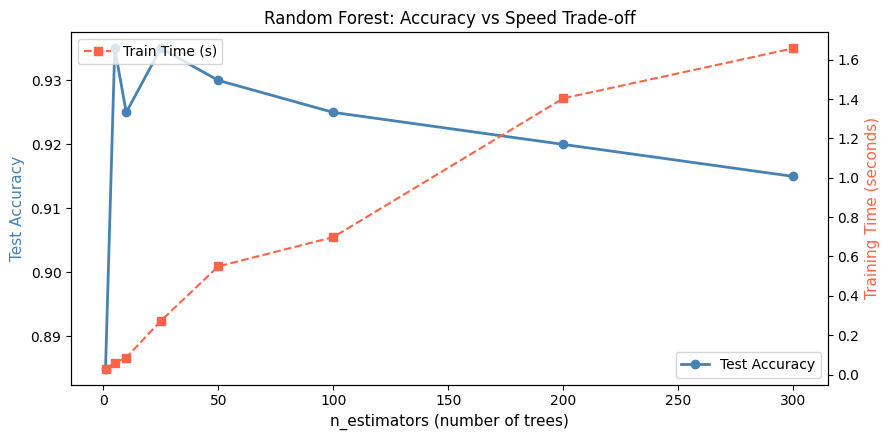

In [18]:
n_trees_list = [1, 5, 10, 25, 50, 100, 200, 300]
accs, times = [], []
for n in n_trees_list:
  t0 = time.time()
  rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
  rf.fit(X_train, y_train)
  accs.append(accuracy_score(y_test, rf.predict(X_test)))
  times.append(time.time() - t0)
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax2 = ax1.twinx()
ax1.plot(n_trees_list, accs, 'o-', color='steelblue', lw=2, label='Test Accuracy')
ax2.plot(n_trees_list, times, 's--', color='tomato', lw=1.5, label='Train Time (s)')
ax1.set_xlabel('n_estimators (number of trees)', fontsize=11)
ax1.set_ylabel('Test Accuracy', color='steelblue', fontsize=11)
ax2.set_ylabel('Training Time (seconds)', color='tomato', fontsize=11)
ax1.set_title('Random Forest: Accuracy vs Speed Trade-off')
ax1.legend(loc='lower right'); ax2.legend(loc='upper left')
plt.tight_layout(); plt.show()

Feature Importance

Random Forest measures how much each feature reduces Gini impurity across all trees and all splits. This gives a feature importance score (0–1, sums to 1.0) — a ranked explanation of what drives predictions.

Feature Importance: Plot, Interpret, and Select

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
import pandas as pd, numpy as np, matplotlib.pyplot as plt

In [21]:
import pandas as pd

import os
if not os.path.exists('diabetes.csv'):
    !wget https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv
df = pd.read_csv('diabetes.csv')
fix_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in fix_cols: df[col] = df[col].replace(0, df[col].median())
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [22]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Feature Importances (higher = more important):')
print(imp.round(3))

Feature Importances (higher = more important):
Glucose                     0.259
BMI                         0.163
Age                         0.147
DiabetesPedigreeFunction    0.117
BloodPressure               0.088
Pregnancies                 0.078
Insulin                     0.076
SkinThickness               0.071
dtype: float64


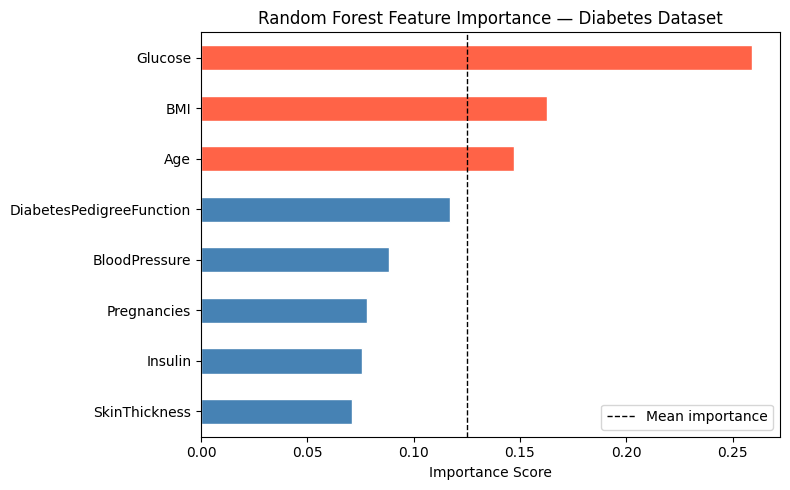

In [23]:
# ■■ Bar chart ■■
imp_sorted = imp.sort_values() # ascending for barh

colors = ['tomato' if g > imp.mean() else 'steelblue' for g in imp_sorted]
imp_sorted.plot(kind='barh', color=colors, figsize=(8,5), edgecolor='white')
plt.axvline(x=imp.mean(), color='black', linestyle='--', linewidth=1, label='Mean importance')
plt.title('Random Forest Feature Importance — Diabetes Dataset', fontsize=12)
plt.xlabel('Importance Score'); plt.legend(); plt.tight_layout(); plt.show()

In [24]:
# ■■ Feature Selection: keep only top features ■■
top_features = imp[imp > imp.mean()].index.tolist()
print(f'\nTop features (above average): {top_features}')
rf_top = RandomForestClassifier(n_estimators=200, random_state=42)
rf_top.fit(X_train[top_features], y_train)
full_acc = rf.score(X_test, y_test)
top_acc = rf_top.score(X_test[top_features], y_test)
print(f'Accuracy with all {len(X.columns)} features : {full_acc:.2%}')
print(f'Accuracy with top {len(top_features)} features : {top_acc:.2%}')
print('Often comparable — low-importance features can add noise!')


Top features (above average): ['Glucose', 'BMI', 'Age']
Accuracy with all 8 features : 77.27%
Accuracy with top 3 features : 72.73%
Often comparable — low-importance features can add noise!
